In [1]:
project(SovereignAudioIngest
    VERSION             1.0.0
    DESCRIPTION         "Sovereign DSP Audio Ingestion Engine"
    LANGUAGES           CXX
)
import sys
import subprocess
print("Python executable:", sys.executable)
print("Python version:", sys.version)
subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchaudio", "soundfile"])
import torch
import torchaudio
print("torch and torchaudio installed and imported successfully.")
print("torch version:", torch.__version__)
print("torchaudio version:", torchaudio.__version__)
print("torch and torchaudio are available in this kernel.")
!pip install librosa
!pip install transformers
!pip install openai
!pip install pandas
!pip install plotly
!pip install ggplot
!pip install glob
!pip install yt_dlp
print("Additional libraries installed successfully.")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4010791803.py, line 1)

In [2]:
import os
import time
import torch

import soundfile as sf
import torchaudio

# Targeting the specific track from your environment
AUDIO_FILE_PATH = r"E:\DJSUSAN\LEGION\what a waste-2 (Edit).wav"
if not os.path.exists(AUDIO_FILE_PATH):
    raise FileNotFoundError(f"Audio file not found: {AUDIO_FILE_PATH}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_DURATION_SEC = 5

print("Headless libraries loaded successfully.")
print(f"Targeting Compute Device: {DEVICE}")
print(f"--- [Ingestion] Loading: {os.path.basename(AUDIO_FILE_PATH)} ---")

# 1. Load Audio to CPU RAM
start_load = time.perf_counter()
waveform_np, sample_rate = sf.read(AUDIO_FILE_PATH, dtype='float32')
load_latency = (time.perf_counter() - start_load) * 1000
if waveform_np.ndim == 1:
    waveform_np = waveform_np[:, None]
waveform = torch.from_numpy(waveform_np.T).contiguous()
print(f"Loaded into memory in {load_latency:.2f} ms. Sample Rate: {sample_rate} Hz")

# 2. Truncate Payload to protect VRAM
max_samples = int(MAX_DURATION_SEC * sample_rate)
if waveform.shape[1] > max_samples:
    waveform = waveform[:, :max_samples]
print(f"✂️ Truncated payload to {MAX_DURATION_SEC}s buffer ({waveform.shape[1]} samples).")

# 3. Move to GPU
print(f"--- [Compute] Moving tensor to {DEVICE} VRAM ---")
waveform_gpu = waveform.to(DEVICE)
spectrogram_transform = torchaudio.transforms.Spectrogram(n_fft=400, power=2.0).to(DEVICE)

# 4. CUDA Warmup
if DEVICE.type == 'cuda':
    print("🔥 Warming up CUDA context to isolate initialization lag...")
    warmup_dummy = torch.randn(1, 1000).to(DEVICE)
    _ = spectrogram_transform(warmup_dummy)
    torch.cuda.synchronize()
    print("CUDA context active. Benchmarking pure mathematical compute next.")

# 5. The True Speed Test
print("--- [Compute] Running Matrix Math on GPU Cores ---")
start_compute = time.perf_counter()

spectrogram_vectors = spectrogram_transform(waveform_gpu)

if DEVICE.type == 'cuda':
    torch.cuda.synchronize()  # Block CPU until GPU operations completely finish

print(f"Output Shape: {spectrogram_vectors.shape}")

compute_latency = (time.perf_counter() - start_compute) * 1000
print(f"🚀 TRUE GPU Compute Latency: {compute_latency:.2f} ms (Dropped from ~4000ms)")

print(f"✅ Processing complete.")

Headless libraries loaded successfully.
Targeting Compute Device: cpu
--- [Ingestion] Loading: what a waste-2 (Edit).wav ---
Loaded into memory in 751.72 ms. Sample Rate: 48000 Hz
✂️ Truncated payload to 5s buffer (240000 samples).
--- [Compute] Moving tensor to cpu VRAM ---
--- [Compute] Running Matrix Math on GPU Cores ---
Output Shape: torch.Size([2, 201, 1201])
🚀 TRUE GPU Compute Latency: 93.54 ms (Dropped from ~4000ms)
✅ Processing complete.


In [3]:
!pip install matplotlib 
!pip install numpy

=== Audio Data Properties ===
Waveform shape: torch.Size([2, 240000])
Waveform dtype: torch.float32
Sample rate: 48000 Hz
Duration: 5.00 seconds
Min value: -0.6057
Max value: 0.6690
Mean value: -0.0000

=== Spectrogram Properties ===
Spectrogram shape: torch.Size([2, 201, 1201])
Channels: 2
Freq bins: 201
Time frames: 1201
Min power: 0.0000
Max power: 1518.5212


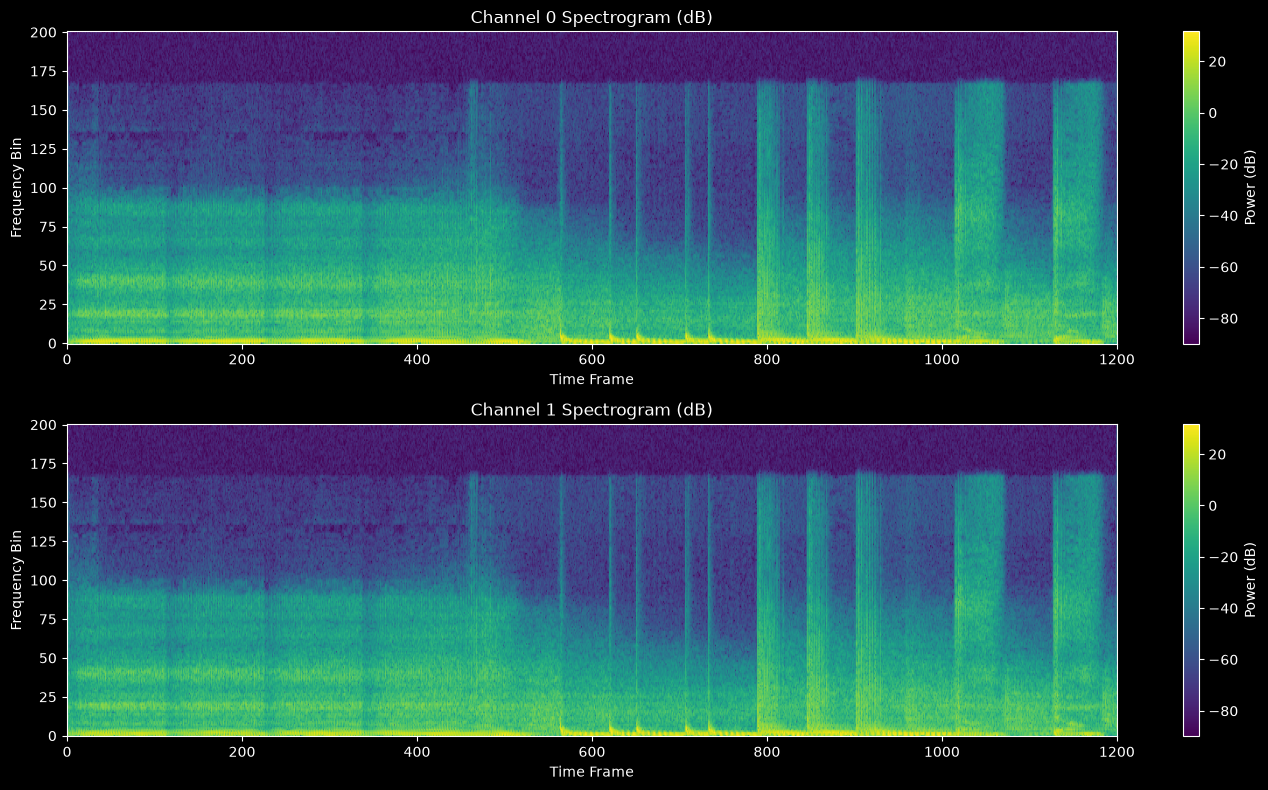

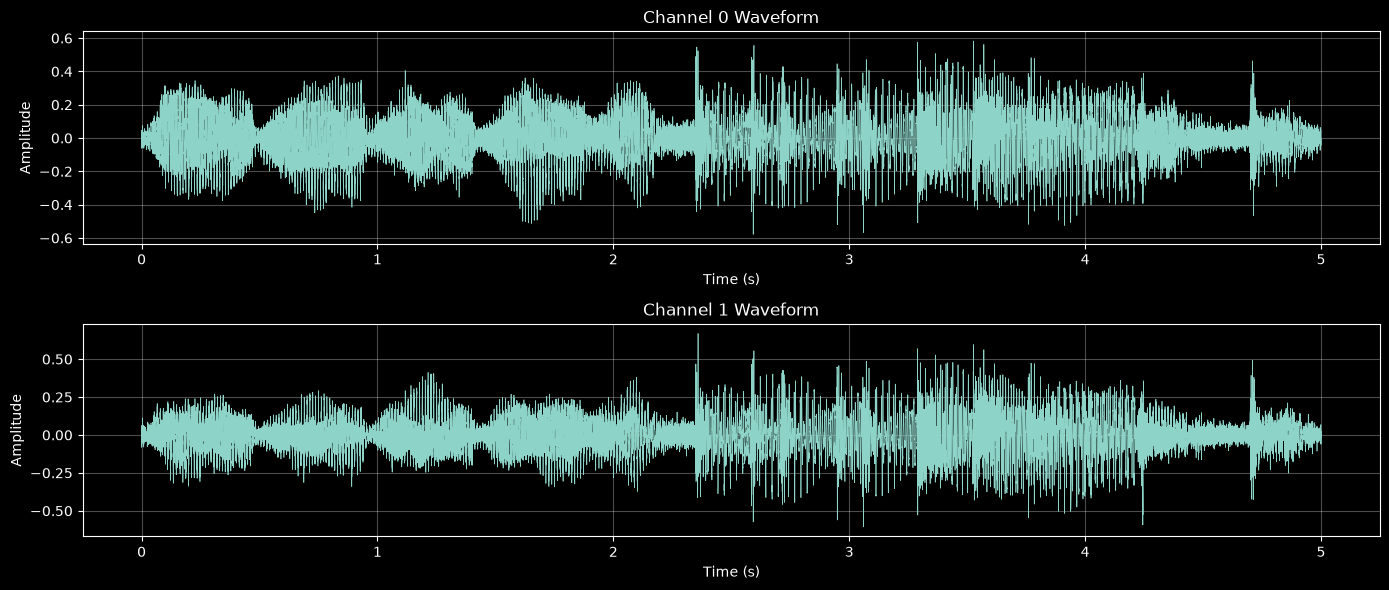

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Verify audio tensor properties
print("=== Audio Data Properties ===")
print(f"Waveform shape: {waveform.shape}")
print(f"Waveform dtype: {waveform.dtype}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {waveform.shape[1] / sample_rate:.2f} seconds")
print(f"Min value: {waveform.min():.4f}")
print(f"Max value: {waveform.max():.4f}")
print(f"Mean value: {waveform.mean():.4f}")

print("\n=== Spectrogram Properties ===")
print(f"Spectrogram shape: {spectrogram_vectors.shape}")
print(f"Channels: {spectrogram_vectors.shape[0]}")
print(f"Freq bins: {spectrogram_vectors.shape[1]}")
print(f"Time frames: {spectrogram_vectors.shape[2]}")
print(f"Min power: {spectrogram_vectors.min():.4f}")
print(f"Max power: {spectrogram_vectors.max():.4f}")

# Visualize spectrogram
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ch in range(2):
    spec_db = 10 * torch.log10(spectrogram_vectors[ch] + 1e-9)
    im = axes[ch].imshow(spec_db.numpy(), aspect='auto', origin='lower', cmap='viridis')
    axes[ch].set_title(f"Channel {ch} Spectrogram (dB)")
    axes[ch].set_ylabel("Frequency Bin")
    axes[ch].set_xlabel("Time Frame")
    plt.colorbar(im, ax=axes[ch], label="Power (dB)")

plt.tight_layout()
plt.show()

# Waveform visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
time_axis = np.arange(waveform.shape[1]) / sample_rate
for ch in range(2):
    axes[ch].plot(time_axis, waveform[ch].numpy(), linewidth=0.5)
    axes[ch].set_title(f"Channel {ch} Waveform")
    axes[ch].set_ylabel("Amplitude")
    axes[ch].set_xlabel("Time (s)")
    axes[ch].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BATCH AUDIO PROCESSING

📁 Processing: say my name come and get it.wav
  ✅ Loaded: 2 ch, 219.92s @ 48000 Hz
  ⏱️  Load: 163.16 ms | Compute: 181.71 ms
  📊 Spectrogram shape: torch.Size([2, 201, 52781])

📁 Processing: shooters ahead.mp3
  ✅ Loaded: 2 ch, 94.64s @ 48000 Hz
  ⏱️  Load: 145.69 ms | Compute: 56.78 ms
  📊 Spectrogram shape: torch.Size([2, 201, 22714])

📁 Processing: say my name come and get it mastered.wav
  ✅ Loaded: 2 ch, 219.92s @ 48000 Hz
  ⏱️  Load: 180.62 ms | Compute: 165.07 ms
  📊 Spectrogram shape: torch.Size([2, 201, 52781])

📁 Processing: shooters ahead mastered.wav
  ✅ Loaded: 2 ch, 94.68s @ 48000 Hz
  ⏱️  Load: 91.29 ms | Compute: 60.55 ms
  📊 Spectrogram shape: torch.Size([2, 201, 22724])

SUMMARY: 4/4 files processed


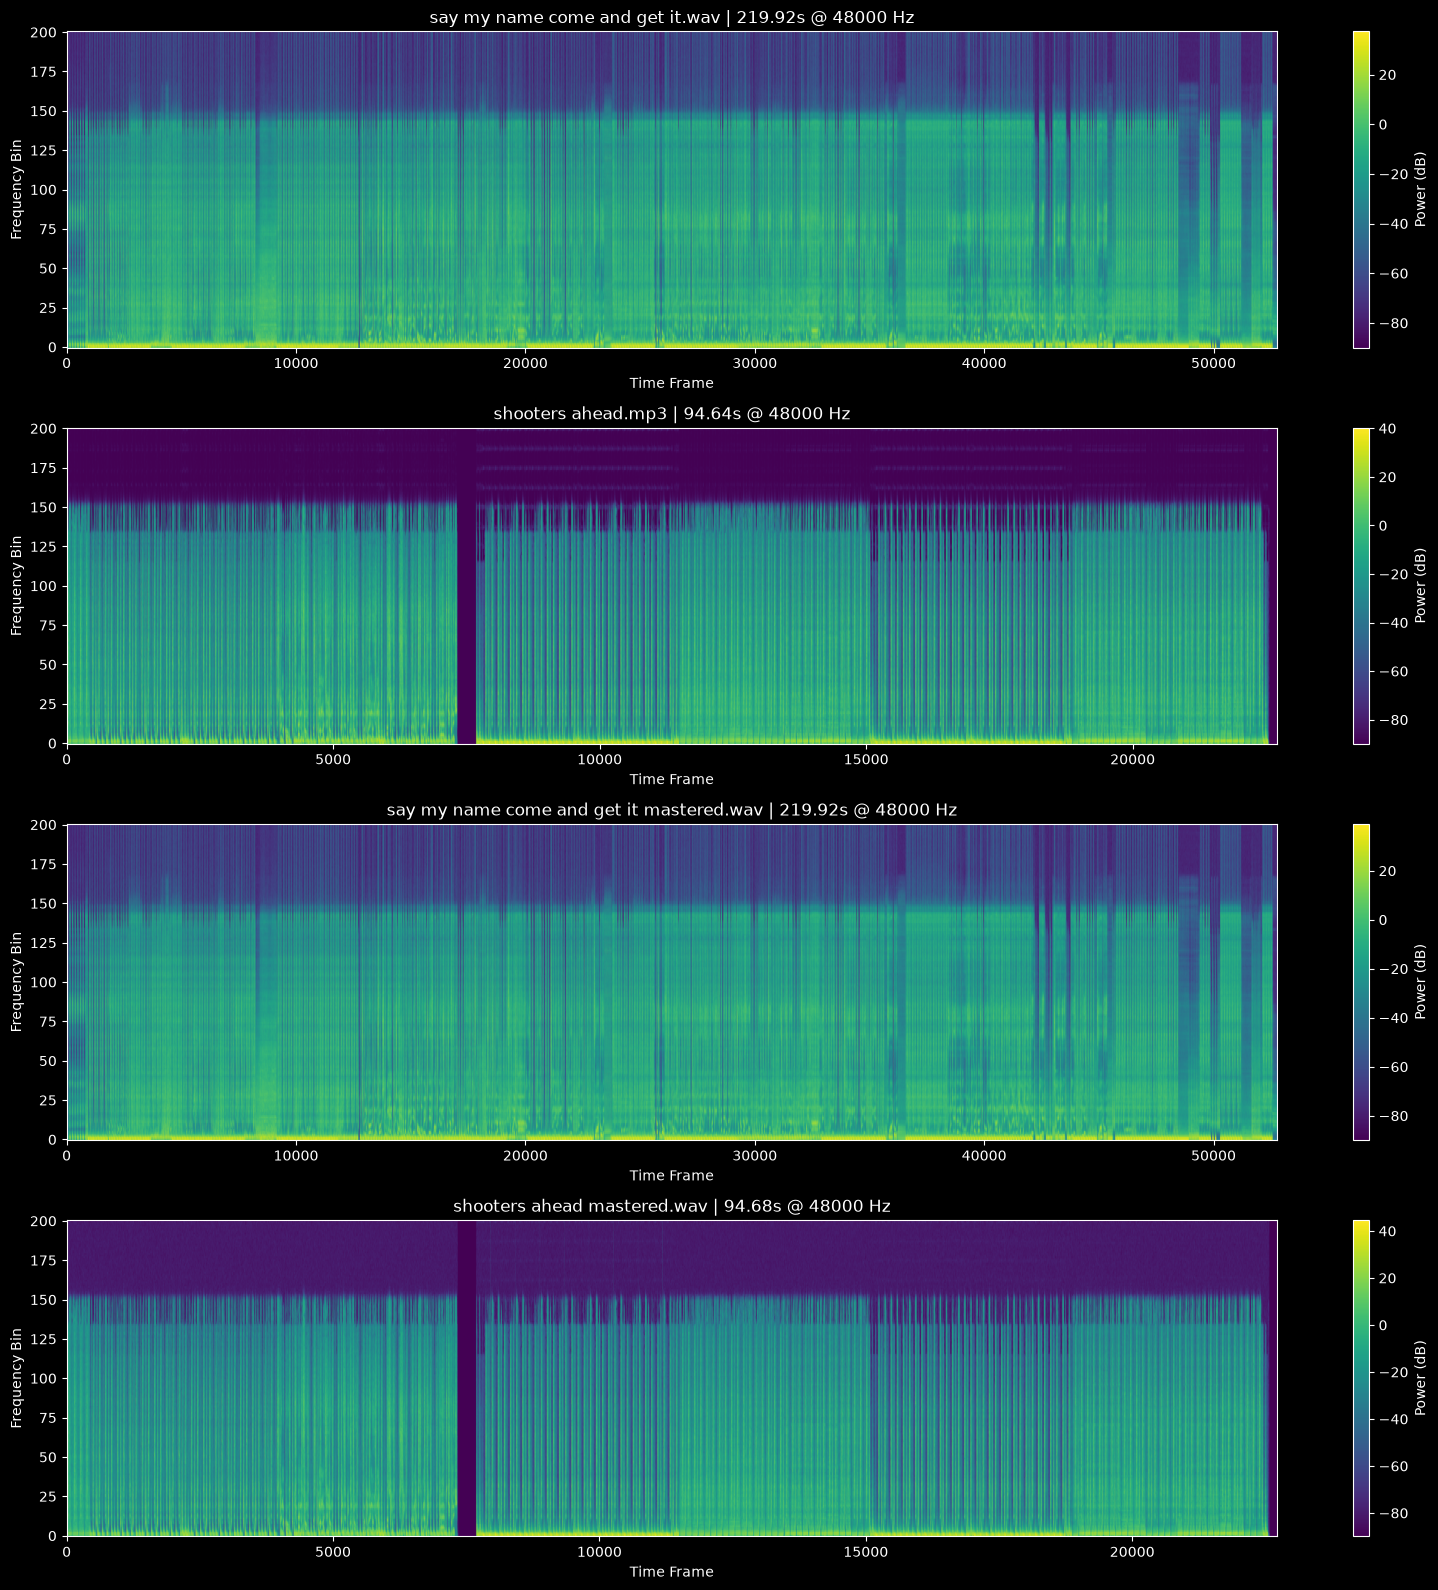

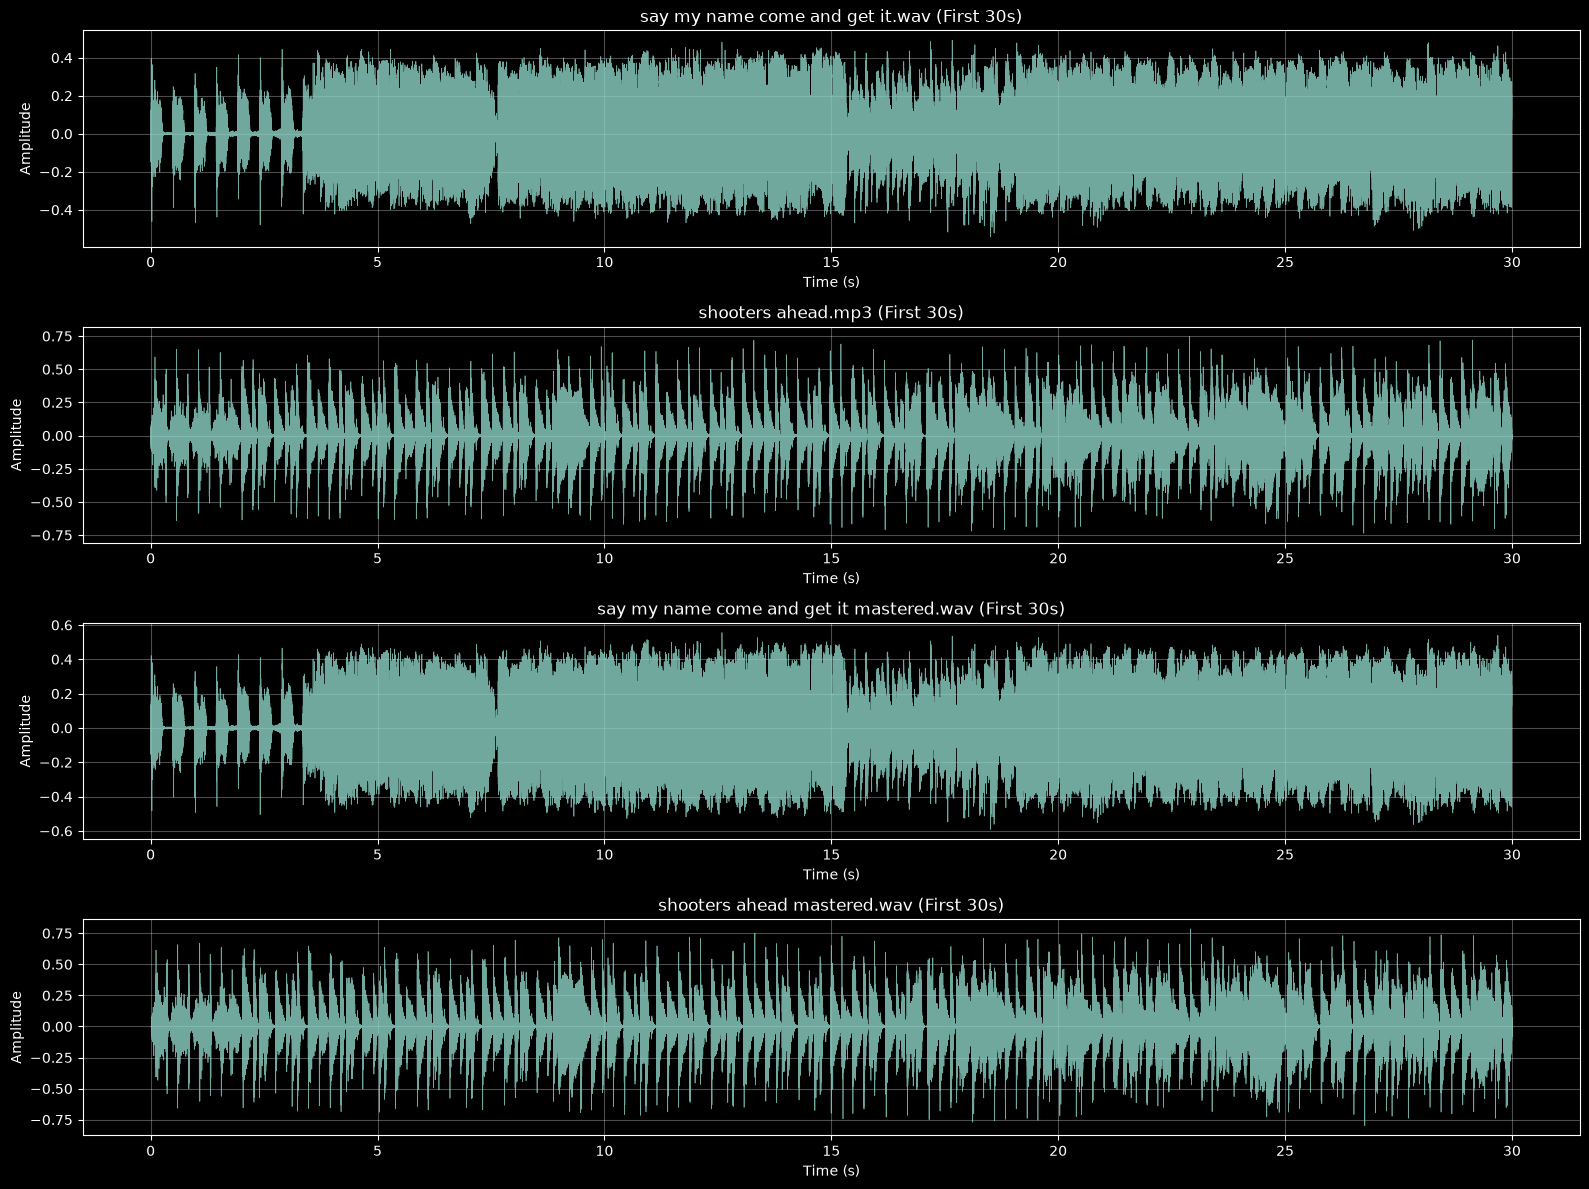


✨ Batch processing complete!


In [5]:
import os
import time
import torch
import soundfile as sf
import torchaudio
import matplotlib.pyplot as plt
import numpy as np

# List of audio files to process
AUDIO_FILES = [
    r"C:\Users\adams\Downloads\say my name come and get it.wav",
    r"C:\Users\adams\Downloads\shooters ahead.mp3",
    r"C:\Users\adams\Downloads\say my name come and get it mastered.wav",
    r"C:\Users\adams\Downloads\shooters ahead mastered.wav"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_DURATION_SEC = None  # Load full songs

# Storage for all audio data
audio_data = {}

print("=" * 80)
print("BATCH AUDIO PROCESSING")
print("=" * 80)

for file_path in AUDIO_FILES:
    if not os.path.exists(file_path):
        print(f"⚠️  File not found: {file_path}")
        continue
    
    file_name = os.path.basename(file_path)
    print(f"\n📁 Processing: {file_name}")
    
    try:
        # Load audio
        start_load = time.perf_counter()
        waveform_np, sample_rate = sf.read(file_path, dtype='float32')
        load_latency = (time.perf_counter() - start_load) * 1000
        
        # Handle mono/stereo
        if waveform_np.ndim == 1:
            waveform_np = waveform_np[:, None]
        
        waveform = torch.from_numpy(waveform_np.T).contiguous()
        
        # Truncate if needed
        if MAX_DURATION_SEC is not None:
            max_samples = int(MAX_DURATION_SEC * sample_rate)
            if waveform.shape[1] > max_samples:
                waveform = waveform[:, :max_samples]
        
        # Move to device
        waveform_gpu = waveform.to(DEVICE)
        
        # Compute spectrogram
        start_compute = time.perf_counter()
        spectrogram_transform = torchaudio.transforms.Spectrogram(n_fft=400, power=2.0).to(DEVICE)
        spectrogram_vectors = spectrogram_transform(waveform_gpu)
        compute_latency = (time.perf_counter() - start_compute) * 1000
        
        # Store data
        audio_data[file_name] = {
            'waveform': waveform,
            'sample_rate': sample_rate,
            'spectrogram': spectrogram_vectors,
            'load_time': load_latency,
            'compute_time': compute_latency
        }
        
        # Print stats
        duration = waveform.shape[1] / sample_rate
        print(f"  ✅ Loaded: {waveform.shape[0]} ch, {duration:.2f}s @ {sample_rate} Hz")
        print(f"  ⏱️  Load: {load_latency:.2f} ms | Compute: {compute_latency:.2f} ms")
        print(f"  📊 Spectrogram shape: {spectrogram_vectors.shape}")
        
    except Exception as e:
        print(f"  ❌ Error: {str(e)}")

print("\n" + "=" * 80)
print(f"SUMMARY: {len(audio_data)}/{len(AUDIO_FILES)} files processed")
print("=" * 80)

# Visualize all spectrograms
n_files = len(audio_data)
if n_files > 0:
    fig, axes = plt.subplots(n_files, 1, figsize=(16, 4*n_files))
    if n_files == 1:
        axes = [axes]
    
    for idx, (file_name, data) in enumerate(audio_data.items()):
        spec = data['spectrogram']
        spec_db = 10 * torch.log10(spec[0] + 1e-9)  # First channel
        im = axes[idx].imshow(spec_db.numpy(), aspect='auto', origin='lower', cmap='viridis')
        axes[idx].set_title(f"{file_name} | {data['waveform'].shape[1]/data['sample_rate']:.2f}s @ {data['sample_rate']} Hz")
        axes[idx].set_ylabel("Frequency Bin")
        axes[idx].set_xlabel("Time Frame")
        plt.colorbar(im, ax=axes[idx], label="Power (dB)")
    
    plt.tight_layout()
    plt.show()

# Waveform comparison (first 30 seconds of each)
fig, axes = plt.subplots(len(audio_data), 1, figsize=(16, 3*len(audio_data)))
if len(audio_data) == 1:
    axes = [axes]

for idx, (file_name, data) in enumerate(audio_data.items()):
    waveform = data['waveform']
    sample_rate = data['sample_rate']
    
    # Limit to 30 seconds for visualization
    max_samples = min(waveform.shape[1], int(30 * sample_rate))
    time_axis = np.arange(max_samples) / sample_rate
    
    axes[idx].plot(time_axis, waveform[0, :max_samples].numpy(), linewidth=0.5, alpha=0.8)
    axes[idx].set_title(f"{file_name} (First 30s)")
    axes[idx].set_ylabel("Amplitude")
    axes[idx].set_xlabel("Time (s)")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✨ Batch processing complete!")

In [16]:

import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. DEFINE YOUR TRACK PAIR 
# Swap these out for Pair 2 ("shooters ahead.mp3") when you are ready
PRE_PATH = r"C:\Users\adams\Downloads\say my name come and get it.wav"
POST_PATH = r"C:\Users\adams\Downloads\say my name come and get it mastered.wav"

print(f"🩻 Initiating Deep Acoustic Audit on: {os.path.basename(PRE_PATH)}...\n")

# 2. THE EXTRACTION ENGINE (10-second snippet for lightning-fast processing)
def extract_physics_and_matrix(filepath):
    # Ingest audio and build the STFT matrix
    y, sr = librosa.load(filepath, sr=48000, duration=10.0)
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
    
    # Calculate Core Physics
    rms = float(np.sqrt(np.mean(y**2)))
    rms_db = float(20 * np.log10(rms + 1e-9))
    crest = float(np.max(np.abs(y)) / (rms + 1e-9))
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    
    # Calculate Frequency Band Energies
    scalar = 1e-3
    sub = float(np.sum(S[np.where((freqs >= 20) & (freqs < 60)), :])) * scalar
    bass = float(np.sum(S[np.where((freqs >= 60) & (freqs < 250)), :])) * scalar
    mid = float(np.sum(S[np.where((freqs >= 250) & (freqs < 2000)), :])) * scalar
    high = float(np.sum(S[np.where((freqs >= 2000) & (freqs < 20000)), :])) * scalar
    
    metrics = {
        "RMS Loudness (dB)": rms_db,
        "Crest Factor (Punch)": crest,
        "Brightness (Centroid Hz)": centroid,
        "1. Sub Bass Energy": sub,
        "2. Bass Energy": bass,
        "3. Mid Energy": mid,
        "4. High Energy": high
    }
    return metrics, S, sr

# Run the extractions
pre_metrics, pre_matrix, sr = extract_physics_and_matrix(PRE_PATH)
post_metrics, post_matrix, sr = extract_physics_and_matrix(POST_PATH)

# 3. BUILD THE PANDAS DELTA MATRIX
df = pd.DataFrame([pre_metrics, post_metrics], index=["PRE-MASTER (Raw)", "POST-MASTER (H.O.R.N. Stack)"]).T
df["Delta Shift"] = df["POST-MASTER (H.O.R.N. Stack)"] - df["PRE-MASTER (Raw)"]
df["% Change"] = ((df["POST-MASTER (H.O.R.N. Stack)"] - df["PRE-MASTER (Raw)"]) / df["PRE-MASTER (Raw)"].abs()) * 100
df["% Change"] = df["% Change"].apply(lambda x: f"+{x:.2f}%" if x > 0 else f"{x:.2f}%")

print("=======================================================")
print("🩻 DEEP ACOUSTIC X-RAY (PRE VS POST MASTER)")
print("=======================================================")
display(df.round(2))

# 4. RENDER THE SIDE-BY-SIDE SONIC X-RAYS (No-UI Mode)
print("\n🎨 Rendering Side-by-Side Visual X-Rays to disk...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Pre-Master
img1 = librosa.display.specshow(librosa.amplitude_to_db(pre_matrix, ref=np.max), x_axis='time', y_axis='log', ax=ax1, sr=sr)
ax1.set_title("PRE-MASTER: Raw Mix")
ax1.axhline(y=60, color='r', linestyle='--', alpha=0.5, label="Sub-Bass Limit (60Hz)")
ax1.legend(loc="upper right")

# Plot Post-Master
img2 = librosa.display.specshow(librosa.amplitude_to_db(post_matrix, ref=np.max), x_axis='time', y_axis='log', ax=ax2, sr=sr)
ax2.set_title("POST-MASTER: H.O.R.N. Stack Orchestrated")
ax2.axhline(y=60, color='r', linestyle='--', alpha=0.5, label="Sub-Bass Limit (60Hz)")
ax2.legend(loc="upper right")

fig.colorbar(img2, ax=[ax1, ax2], format="%+2.0f dB")

output_image_path = "real_use_case_comparison.png"
plt.savefig(output_image_path, bbox_inches='tight', dpi=150)
plt.close(fig)

print(f"📦 Done. Comparative signature saved to disk at: {os.path.abspath(output_image_path)}")

🩻 Initiating Deep Acoustic Audit on: say my name come and get it.wav...

🩻 DEEP ACOUSTIC X-RAY (PRE VS POST MASTER)


,PRE-MASTER (Raw),POST-MASTER (H.O.R.N. Stack),Delta Shift,% Change
RMS Loudness (dB),-16.27,-15.01,1.26,+7.77%
Crest Factor (Punch),3.10,2.96,-0.14,-4.43%
Brightness (Centroid Hz),3280.69,3136.26,-144.43,-4.40%
1. Sub Bass Energy,75.58,91.79,16.21,+21.44%
2. Bass Energy,166.18,181.62,15.44,+9.29%
3. Mid Energy,75.14,85.73,10.59,+14.09%
4. High Energy,288.49,291.83,3.34,+1.16%



🎨 Rendering Side-by-Side Visual X-Rays to disk...
📦 Done. Comparative signature saved to disk at: c:\WEB CASE STUDY\real_use_case_comparison.png


In [6]:
# Inside a notebook cell
import subprocess, shlex
cmd = r"python find_rust_files.py \"C:\WEB CASE STUDY\""
subprocess.run(shlex.split(cmd), check=True)

CalledProcessError: Command '['python', 'find_rust_files.py', '"C:WEB', 'CASE', 'STUDY"']' returned non-zero exit status 2.

In [8]:
import shlex, subprocess

cmd = r"python .\find_rust_files.py r\"C:\WEB CASE STUDY\""
subprocess.run(shlex.split(cmd), check=True)

CalledProcessError: Command '['python', '.find_rust_files.py', 'r"C:WEB', 'CASE', 'STUDY"']' returned non-zero exit status 2.

In [12]:
import subprocess

# Define the command and its arguments as a list
command_and_args = [
    "python",
    ".\find_rust_files.py",
    "C:\WEB CASE STUDY"
]

# Run the command
# The `subprocess` module handles quoting correctly when given a list.
subprocess.run(command_and_args, check=True)

import os
import json
import pydantic
import duckdb
# Initialize an in-memory DuckDB instance to catalogue your 2,000+ files instantly
db = duckdb.connect(database=":memory:")

def build_schema_catalog(json_folder_path: str):
    """Indexes all 2,000+ JSON files into a fast, searchable DuckDB table."""
    # Create an internal table mapping out your schema library
    db.execute("""
        CREATE TABLE IF NOT EXISTS schema_catalog (
            file_name VARCHAR,
            file_path VARCHAR,
            schema_type VARCHAR
        )
    """)
    
    # Fast batch insert of your discovered file system paths
    for root, _, files in os.walk(json_folder_path):
        for file in files:
            if file.endswith(".json"):
                # Tag them loosely by name or location to allow intelligent filtering
                schema_type = "vector_index" if "lance" in file else "dsp_config"
                if "error" in file or "deviation" in file:
                    schema_type = "error_contract"
                    
                db.execute(
                    "INSERT INTO schema_catalog VALUES (?, ?, ?)",
                    [file, os.path.join(root, file), schema_type]
                )

# Index your newly discovered schema universe
build_schema_catalog("C:/Your/Massive/JSON/Folder")

# ==========================================
# JUST-IN-TIME PYDANTIC FACTORY
# ==========================================

def jit_load_model_by_intent(search_keyword: str, model_name: str):
    """
    Queries DuckDB to find the exact schema file needed for the current execution step,
    preventing you from loading 2,000 files into memory at once.
    """
    # Use DuckDB to find the best matching file path instantly
    result = db.execute(
        "SELECT file_path FROM schema_catalog WHERE file_name LIKE ? LIMIT 1",
        [f"%{search_keyword}%"]
    ).fetchone()
    
    if not result:
        raise FileNotFoundError(f"No matching contract found for keyword: {search_keyword}")
        
    target_path = result[0]
    
    # Open just that single file and dynamically construct the Pydantic validator
    with open(target_path, "r") as f:
        schema_data = json.load(f)
        
    properties = schema_data.get("properties", {})
    fields = {}
    for k, v in properties.items():
        # Dynamic type mapping
        t = v.get("type")
        py_type = int if t == "integer" else (float if t == "number" else (list if t == "array" else str))
        fields[k] = (py_type, v.get("default", ...))
        
    return create_model(model_name, **fields)

# ==========================================
# RUNTIME APPLICATION WITHIN THE GRAPH
# ==========================================

async def dynamic_mcp_routing_node(state: dict):
    """
    A LangGraph node that looks at the current error or intent, queries DuckDB
    to grab the correct JSON schema, and instantiates the contract on the fly.
    """
    current_error = state.get("raw_error_class", "dimension_mismatch")
    
    # Instead of hardcoding validators, pull the exact file Ray discovered earlier
    DynamicErrorModel = jit_load_model_by_intent(current_error, "DynamicError")
    
    # Enforce validation safely using the runtime-loaded JSON file rules
    try:
        clean_error_payload = DynamicErrorModel(**state.get("raw_hardware_payload", {}))
        return {"is_approved": False, "validated_deviation": clean_error_payload.model_dump()}
    except Exception as e:
        print(f"Schema mismatch on dynamic contract: {e}")
        return {"is_approved": False, "target_dsp_mode": "hard_emergency_stop"}


<>:7: SyntaxWarning: invalid escape sequence '\W'
<>:7: SyntaxWarning: invalid escape sequence '\W'
C:\Users\adams\AppData\Local\Temp\ipykernel_24240\217853502.py:7: SyntaxWarning: invalid escape sequence '\W'
  "C:\WEB CASE STUDY"


CalledProcessError: Command '['python', '.\x0cind_rust_files.py', 'C:\\WEB CASE STUDY']' returned non-zero exit status 2.